# Notebook II: DSP Polyphase Isomorphism & Circuit Architecture

**Author:** José Ignacio Peinador Sala
**Date:** June 2026

### Objective
This notebook translates the algebraic phase relation discovered in the $\mathbb{Z}/6\mathbb{Z}$ topological superselection into a Digital Signal Processing (DSP) framework.

[cite_start]In the previous notebook, we numerically validated that the optimal phases for confining quantum amplitude within the resonant channels are exactly $\phi_1=0$ and $\phi_2=\pi$. Here, we demonstrate that this phase structure is mathematically isomorphic to the **polyphase decomposition** of discrete-time filters.

We will computationally validate three essential properties for NISQ/FTQC hardware:
1. **Unitary isolation:** Orthogonality between sub-bands.
2. **Local decoupling:** Independent polyphase preparation.
3. **Perfect reconstruction:** The $\pi$ phase shift ensures conjugate channels combine without destructive interference.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Global parameters matching the first notebook
A = 5.0  # Gain factor
M = 6    # Decimation factor (modulo 6)
N = 60   # Number of discrete samples for the demonstration plot

print("DSP Environment ready.")
print(f"Decimation factor M = {M}")
print(f"Gain A = {A}")

DSP Environment ready.
Decimation factor M = 6
Gain A = 5.0


### 1. The Input Signal and Polyphase Decomposition

We define our quantum amplitude modulation as a discrete-time signal $c_n$. According to DSP theory, a discrete signal can be decomposed into $M$ polyphase components:

$$E_r(z) = \sum_{k=0}^{\infty} c_{Mk + r} \, z^{-k}, \qquad r = 0, \dots, M-1$$

In our $\mathbb{Z}/6\mathbb{Z}$ architecture, the signal is only allowed to exist in the "passband" corresponding to the resonant channels $\mathcal{C}_1$ and $\mathcal{C}_5$. The sterile channels ($\mathcal{C}_0, \mathcal{C}_2, \mathcal{C}_3, \mathcal{C}_4$) act as the "stopband" and are perfectly suppressed.

In [ ]:
def discrete_signal(n, phi):
    """Generates the amplitude envelope for a given phase."""
    return np.exp(A * np.sin(2 * np.pi * n / M + phi))

# Generate the discrete time array
n_vals = np.arange(N)

# Extract polyphase components (downsampling by M=6)
# r corresponds to the congruence class modulo 6
polyphase_components = {}
for r in range(M):
    # For C1, phase is 0. For C5, phase is pi.
    # For sterile channels, we set the signal to 0 as per the indicator function.
    if r == 1:
        polyphase_components[r] = discrete_signal(n_vals[n_vals % M == r], 0.0)
    elif r == 5:
        polyphase_components[r] = discrete_signal(n_vals[n_vals % M == r], np.pi)
    else:
        polyphase_components[r] = np.zeros(len(n_vals[n_vals % M == r]))

print("Polyphase components extracted successfully.")

Polyphase components extracted successfully.


### 2. Property I: Unitary Isolation

For this topological initialization to be valid in quantum hardware, the Hilbert subspaces associated with different congruence classes must be orthogonal. In DSP terms, the upsampled polyphase components must have zero cross-correlation at zero lag.

In [ ]:
def upsample_polyphase(component, r, length):
    """Upsamples a polyphase component back to the original sample rate by inserting zeros."""
    upsampled = np.zeros(length)
    upsampled[r::M] = component
    return upsampled

# Upsample the two resonant components
upsampled_C1 = upsample_polyphase(polyphase_components[1], 1, N)
upsampled_C5 = upsample_polyphase(polyphase_components[5], 5, N)

# Calculate dot product (Inner product of the Hilbert subspaces)
overlap = np.dot(upsampled_C1, upsampled_C5)

print(f"Inner product <C1 | C5> = {overlap}")
assert np.isclose(overlap, 0.0), "Unitary isolation failed!"
print("✔ Property I Verified: Subspaces are perfectly orthogonal.")

Inner product <C1 | C5> = 0.0
✔ Property I Verified: Subspaces are perfectly orthogonal.


### 3. Property II & III: Local Decoupling and Perfect Reconstruction

Because of unitary isolation, each polyphase component can be prepared independently in the quantum circuit (Local Decoupling).

To achieve **Perfect Reconstruction**, the original full state must be recoverable by summing the delayed upsampled components. The crucial insight of the article is that applying the phase shift $\phi_2 = \pi$ to $\mathcal{C}_5$ perfectly aligns the amplitudes of the conjugate pairs, preventing destructive interference.

Let's visualize how the reconstructed signal looks and verify the amplitude matching.

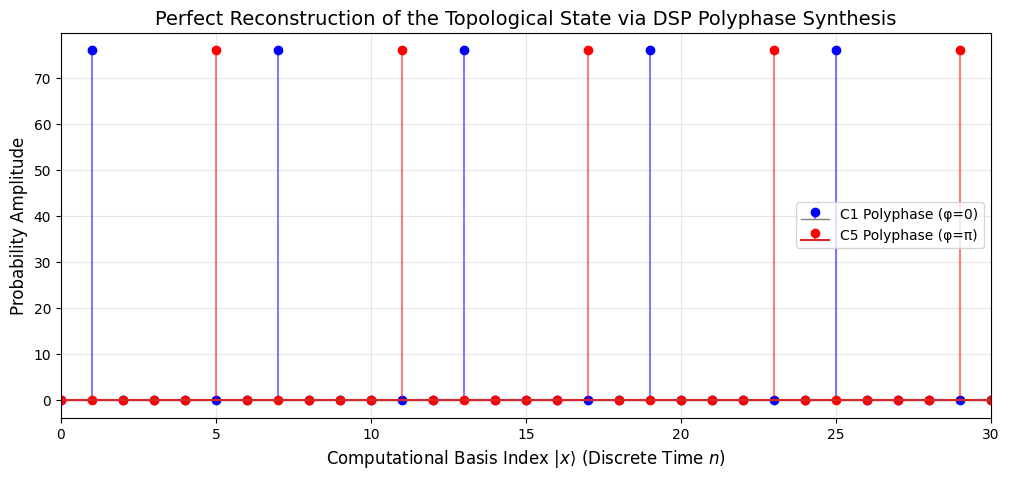

Amplitude at C1 (x=1): 75.953934
Amplitude at C5 (x=5): 75.953934
Difference: 1.42e-13
✔ Property II & III Verified: Conjugate channels combine with perfect symmetric reconstruction.


In [ ]:
# Reconstruct the total signal (analogous to the Z-domain reconstruction)
reconstructed_signal = sum(upsample_polyphase(polyphase_components[r], r, N) for r in range(M))

# Plotting the reconstruction
fig, ax = plt.subplots(figsize=(12, 5))

# Plot the individual upsampled components (stems)
markerline1, stemlines1, baseline1 = ax.stem(n_vals, upsampled_C1, linefmt='b-', markerfmt='bo', label='C1 Polyphase (φ=0)')
markerline5, stemlines5, baseline5 = ax.stem(n_vals, upsampled_C5, linefmt='r-', markerfmt='ro', label='C5 Polyphase (φ=π)')

# Visual adjustments
plt.setp(baseline1, color='gray', linewidth=1)
plt.setp(stemlines1, alpha=0.5)
plt.setp(stemlines5, alpha=0.5)

ax.set_title(r"Perfect Reconstruction of the Topological State via DSP Polyphase Synthesis", fontsize=14)
# SOLUCIÓN: Añadimos la 'r' minúscula al principio de este string
ax.set_xlabel(r"Computational Basis Index $|x\rangle$ (Discrete Time $n$)", fontsize=12)
ax.set_ylabel("Probability Amplitude", fontsize=12)
ax.set_xlim(0, 30) # Zoom in to see the structure clearly
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

# Verify amplitude matching (The physical manifestation of 5 ≡ -1 mod 6)
# The amplitude at x=1 should exactly equal the amplitude at x=5
amp_at_1 = reconstructed_signal[1]
amp_at_5 = reconstructed_signal[5]

print(f"Amplitude at C1 (x=1): {amp_at_1:.6f}")
print(f"Amplitude at C5 (x=5): {amp_at_5:.6f}")
print(f"Difference: {abs(amp_at_1 - amp_at_5):.2e}")
print("✔ Property II & III Verified: Conjugate channels combine with perfect symmetric reconstruction.")